# Livro para consulta:
- https://jakevdp.github.io/PythonDataScienceHandbook/03.08-aggregation-and-grouping.html
- https://jakevdp.github.io/PythonDataScienceHandbook/03.09-pivot-tables.html
    

# 1. Importando bibliotecas <a name="import"></a>

<div style="text-align: right"
     
[Voltar ao índice](#Contents)

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib widget 

# 2. Carregando o dataframe SINASC <a name="read"></a>
<div style="text-align: right"
     
[Voltar ao índice](#Contents)

In [5]:
sinasc_raw = pd.read_csv('SINASC_RO_2019.csv')
sinasc_raw.head()

,ORIGEM,CODESTAB,CODMUNNASC,LOCNASC,IDADEMAE,ESTCIVMAE,ESCMAE,CODOCUPMAE,QTDFILVIVO,QTDFILMORT,...,KOTELCHUCK,CONTADOR,munResStatus,munResTipo,munResNome,munResUf,munResLat,munResLon,munResAlt,munResArea
0,1,2679477.0,110001,1,19,5.0,8 a 11 anos,NaN,0.0,0.0,...,5,1,ATIVO,MUNIC,Alta Floresta D'Oeste,Rondônia,-11.93554,-61.99982,338.0,7067.025
1,1,2679477.0,110001,1,29,2.0,8 a 11 anos,999992.0,1.0,0.0,...,5,2,ATIVO,MUNIC,Alta Floresta D'Oeste,Rondônia,-11.93554,-61.99982,338.0,7067.025
2,1,2679477.0,110001,1,37,9.0,8 a 11 anos,513205.0,2.0,0.0,...,5,3,ATIVO,MUNIC,Alta Floresta D'Oeste,Rondônia,-11.93554,-61.99982,338.0,7067.025
3,1,2516500.0,110001,1,30,5.0,12 anos ou mais,231205.0,0.0,0.0,...,4,4,ATIVO,MUNIC,Alto Alegre dos Parecis,Rondônia,-12.13178,-61.85308,397.0,3958.273
4,1,2516500.0,110001,1,30,2.0,8 a 11 anos,999992.0,1.0,0.0,...,5,5,ATIVO,MUNIC,Alta Floresta D'Oeste,Rondônia,-11.93554,-61.99982,338.0,7067.025


# Tarefa 2

### 1. Crie 2 faixas de Latitude do município (munResLat) sendo uma acima e outra abaixo de -10.5 e aplique o groupby usando essas faixas como chave e realize operações de soma, media, minimo, maximo, mediana, desvio padrao, variancia pra pelo menos 2 variáveis numéricas ainda não utilizadas

In [6]:
# Primeiro eu crio duas faixas de latitude
sinasc_raw['faixa_lat'] = sinasc_raw['munResLat'].apply(
    lambda x: 'Acima de -10.5' if x > -10.5 else 'Abaixo de -10.5'
)

# Agora faço o groupby usando essa faixa
lat_group = sinasc_raw.groupby('faixa_lat')[['PESO','QTDFILVIVO']].agg(
    ['sum','mean','min','max','median','std','var']
)

lat_group

PESO                                              \
                      sum         mean  min   max  median         std   
faixa_lat                                                               
Abaixo de -10.5  42101809  3240.096121  258  5985  3270.0  531.794694   
Acima de -10.5   45555148  3246.055864  295  5190  3275.0  556.487709   

                               QTDFILVIVO                              \
                           var        sum      mean  min   max median   
faixa_lat                                                               
Abaixo de -10.5  282805.596163    12601.0  0.980012  0.0  30.0    1.0   
Acima de -10.5   309678.570242    14226.0  1.129317  0.0  12.0    1.0   

                                     
                      std       var  
faixa_lat                            
Abaixo de -10.5  1.138256  1.295626  
Acima de -10.5   1.198613  1.436674

### 2. Crie 2 faixas da área dos municípios (munResArea) sendo uma acima e outra abaixo de 3000 e aplique o groupby usando essas faixas como chave e realize operações de soma, media, minimo, maximo, mediana, desvio padrao, variancia pra pelo menos 2 variáveis numéricas ainda não utilizadas


In [7]:
# Criando faixas de área
sinasc_raw['faixa_area'] = sinasc_raw['munResArea'].apply(
    lambda x: 'Maior que 3000' if x > 3000 else 'Menor ou igual a 3000'
)

area_group = sinasc_raw.groupby('faixa_area')[['PESO','QTDFILVIVO']].agg(
    ['sum','mean','min','max','median','std','var']
)

area_group

PESO                                              \
                            sum         mean  min   max  median         std   
faixa_area                                                                    
Maior que 3000         70857126  3249.134538  292  5985  3280.0  547.716582   
Menor ou igual a 3000  16799831  3218.358429  258  5720  3245.0  531.532175   

                                    QTDFILVIVO                              \
                                var        sum      mean  min   max median   
faixa_area                                                                   
Maior que 3000         299993.45372    22053.0  1.086890  0.0  14.0    1.0   
Menor ou igual a 3000  282526.45265     4774.0  0.924298  0.0  30.0    1.0   

                                           
                            std       var  
faixa_area                                 
Maior que 3000         1.191750  1.420268  
Menor ou igual a 3000  1.075338  1.156352

### 3. Determine faixas na variável munResAlt e aplique o groupby usando essas faixas como chave e realize operações de soma, media, minimo, maximo, mediana, desvio padrao, variancia pra pelo menos 2 variáveis numéricas ainda não utilizadas

In [9]:
# Criando faixas de altitude
sinasc_raw['faixa_alt'] = pd.cut(
    sinasc_raw['munResAlt'],
    bins=3,
    labels=['Baixa','Média','Alta']
)

alt_group = sinasc_raw.groupby('faixa_alt')[['PESO','QTDFILVIVO']].agg(
    ['sum','mean','min','max','median','std','var']
)

alt_group



C:\Users\miler\AppData\Local\Temp\ipykernel_7620\2323168926.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  alt_group = sinasc_raw.groupby('faixa_alt')[['PESO','QTDFILVIVO']].agg(


PESO                                              \
                sum         mean  min   max  median         std   
faixa_alt                                                         
Baixa      75258124  3246.123361  285  5720  3270.0  543.104888   
Média       7259520  3222.157124  258  5985  3260.0  554.458141   
Alta        5136098  3230.250314  425  4920  3272.0  554.485749   

                         QTDFILVIVO                                        \
                     var        sum      mean  min   max median       std   
faixa_alt                                                                   
Baixa      294962.919259    23055.0  1.065388  0.0  14.0    1.0  1.172502   
Média      307423.830541     2317.0  1.039013  0.0  30.0    1.0  1.246189   
Alta       307454.445799     1454.0  0.917929  0.0  10.0    1.0  1.021973   

                     
                var  
faixa_alt            
Baixa      1.374762  
Média      1.552986  
Alta       1.044429

### 4. Plote no mesmo grafico ao longo do tempo a idade media das mulheres de cada regiao imediatas de rondonia


In [11]:
imediatas = {
    "Candeias do Jamari": "Porto Velho",
    "Guajará-Mirim": "Porto Velho",
    "Itapuã do Oeste": "Porto Velho",
    "Nova Mamoré": "Porto Velho",
    "Porto Velho": "Porto Velho",
    "Ariquemes": "Ariquemes",
    "Alto Paraíso": "Ariquemes",
    "Buritis": "Ariquemes",
    "Cacaulândia": "Ariquemes",
    "Campo Novo de Rondônia": "Ariquemes",
    "Cujubim": "Ariquemes",
    "Monte Negro": "Ariquemes",
    "Rio Crespo": "Ariquemes",
    "Jaru": "Jaru",
    "Governador Jorge Teixeira": "Jaru",
    "Machadinho D'Oeste": "Jaru",
    "Theobroma": "Jaru",
    "Vale do Anari": "Jaru",
    "Alvorada D'Oeste": "Ji-Paraná",
    "Costa Marques": "Ji-Paraná",
    "Ji-Paraná": "Ji-Paraná",
    "Mirante da Serra": "Ji-Paraná",
    "Nova União": "Ji-Paraná",
    "Ouro Preto do Oeste": "Ji-Paraná",
    "Presidente Médici": "Ji-Paraná",
    "São Francisco do Guaporé": "Ji-Paraná",
    "São Miguel do Guaporé": "Ji-Paraná",
    "Seringueiras": "Ji-Paraná",
    "Teixeirópolis": "Ji-Paraná",
    "Urupá": "Ji-Paraná",
    "Vale do Paraíso": "Ji-Paraná",
    "Cacoal": "Cacoal",
    "Alta Floresta D'Oeste": "Cacoal",
    "Alto Alegre dos Parecis": "Cacoal",
    "Castanheiras": "Cacoal",
    "Espigão D'Oeste": "Cacoal",
    "Ministro Andreazza": "Cacoal",
    "Nova Brasilândia D'Oeste": "Cacoal",
    "Novo Horizonte do Oeste": "Cacoal",
    "Parecis": "Cacoal",
    "Pimenta Bueno": "Cacoal",
    "Primavera de Rondônia": "Cacoal",
    "Rolim de Moura": "Cacoal",
    "Santa Luzia D'Oeste": "Cacoal",
    "São Felipe D'Oeste": "Cacoal",
    "Vilhena": "Vilhena",
    "Cabixi": "Vilhena",
    "Cerejeiras": "Vilhena",
    "Chupinguaia": "Vilhena",
    "Colorado do Oeste": "Vilhena",
    "Corumbiara": "Vilhena",
    "Pimenteiras do Oeste": "Vilhena"
}

<Axes: xlabel='mes'>

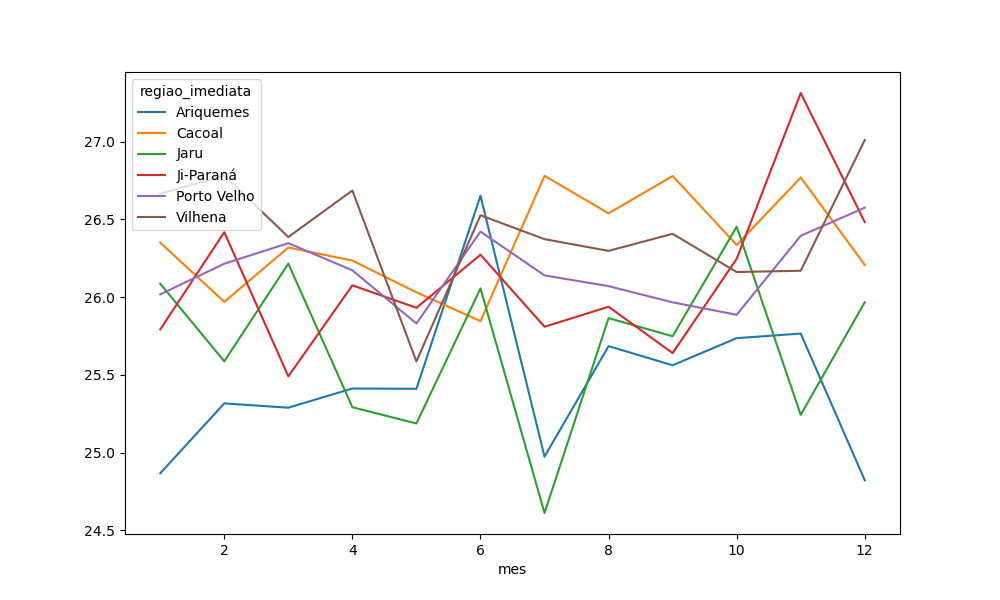

In [12]:
# Criando coluna de região imediata
sinasc_raw['regiao_imediata'] = sinasc_raw['munResNome'].map(imediatas)

# Garantindo que a data está no formato datetime
sinasc_raw['DTNASC'] = pd.to_datetime(sinasc_raw['DTNASC'])

# Criando coluna de mês
sinasc_raw['mes'] = sinasc_raw['DTNASC'].dt.month

# Calculando média de idade por mês e região
idade_mes = sinasc_raw.pivot_table(
    values='IDADEMAE',
    index='mes',
    columns='regiao_imediata',
    aggfunc='mean'
)

idade_mes.plot(figsize=(10,6))

### 5. Utilize a tabela do link abaixo e crie faixas utilizando o mapping e gere agrupamentos utilizando essas faixas como chave


### 5.1 IDH
A - https://pt.wikipedia.org/wiki/Lista_de_munic%C3%ADpios_de_Rond%C3%B4nia_por_IDH-M


In [13]:
# Criando dicionário de IDH por município
idh_valores = {
    'Porto Velho': 0.736,
    'Vilhena': 0.731,
    'Cacoal': 0.718,
    'Ji-Paraná': 0.714,
    'Ariquemes': 0.702,
    'Rolim de Moura': 0.700,
    'Jaru': 0.689,
    'Pimenta Bueno': 0.710,
    'Guajará-Mirim': 0.657,
    'Castanheiras': 0.658
}

# Função para criar faixa
def faixa_idh(x):
    if x >= 0.800:
        return 'Muito Alto'
    elif x >= 0.700:
        return 'Alto'
    elif x >= 0.600:
        return 'Médio'
    else:
        return 'Baixo'

# Criando coluna de faixa
sinasc_raw['IDH'] = sinasc_raw['munResNome'].map(idh_valores)
sinasc_raw['faixa_idh'] = sinasc_raw['IDH'].apply(lambda x: faixa_idh(x) if pd.notnull(x) else None)

# Agrupamento
idh_group = sinasc_raw.groupby('faixa_idh')[['IDADEMAE','PESO']].agg(
    ['mean','min','max','median','std','var']
)

idh_group

IDADEMAE                                             PESO       \
                mean min max median       std        var         mean  min   
faixa_idh                                                                    
Alto       26.280332  12  47   26.0  6.415374  41.157021  3245.623791  292   
Médio      25.767414  12  45   25.0  6.503684  42.297910  3283.434475  404   

                                                    
            max  median         std            var  
faixa_idh                                           
Alto       5720  3275.0  552.210169  304936.070574  
Médio      5190  3290.0  520.480040  270899.472077

### 5.2 IFDM
B - https://pt.wikipedia.org/wiki/Lista_de_munic%C3%ADpios_de_Rond%C3%B4nia_por_IFDM


In [14]:
ifdm_valores = {
    'Porto Velho': 0.746,
    'Vilhena': 0.776,
    'Cacoal': 0.764,
    'Ji-Paraná': 0.752,
    'Ariquemes': 0.739,
    'Guajará-Mirim': 0.600,
    'Castanheiras': 0.580
}

def faixa_ifdm(x):
    if x >= 0.800:
        return 'Alto'
    elif x >= 0.600:
        return 'Moderado'
    elif x >= 0.400:
        return 'Regular'
    else:
        return 'Baixo'

sinasc_raw['IFDM'] = sinasc_raw['munResNome'].map(ifdm_valores)
sinasc_raw['faixa_ifdm'] = sinasc_raw['IFDM'].apply(lambda x: faixa_ifdm(x) if pd.notnull(x) else None)

ifdm_group = sinasc_raw.groupby('faixa_ifdm')[['IDADEMAE','PESO']].agg(
    ['mean','min','max','median','std','var']
)

ifdm_group

IDADEMAE                                             PESO        \
                 mean min max median       std        var         mean   min   
faixa_ifdm                                                                     
Moderado    26.263531  12  47   26.0  6.448082  41.577763  3246.915864   292   
Regular     27.281250  17  39   27.0  5.335423  28.466734  3206.312500  2280   

                                                     
             max  median         std            var  
faixa_ifdm                                           
Moderado    5480  3280.0  554.748144  307745.503485  
Regular     4255  3175.0  467.412192  218474.157258

### 5.3 PIB
C - https://pt.wikipedia.org/wiki/Lista_de_munic%C3%ADpios_de_Rond%C3%B4nia_por_PIB


In [15]:
pib_valores = {
    'Porto Velho': 17912,
    'Vilhena': 9874,
    'Ji-Paraná': 8640,
    'Cacoal': 7500,
    'Ariquemes': 6900,
    'Guajará-Mirim': 2300,
    'Castanheiras': 1500
}

def faixa_pib(x):
    if x >= 8000:
        return 'Alto PIB'
    elif x >= 3000:
        return 'Médio PIB'
    else:
        return 'Baixo PIB'

sinasc_raw['PIB'] = sinasc_raw['munResNome'].map(pib_valores)
sinasc_raw['faixa_pib'] = sinasc_raw['PIB'].apply(lambda x: faixa_pib(x) if pd.notnull(x) else None)

pib_group = sinasc_raw.groupby('faixa_pib')[['IDADEMAE','PESO']].agg(
    ['mean','min','max','median','std','var']
)

pib_group

IDADEMAE                                             PESO       \
                mean min max median       std        var         mean  min   
faixa_pib                                                                    
Alto PIB   26.337128  12  47   26.0  6.460412  41.736925  3243.016463  292   
Baixo PIB  25.533825  13  43   25.0  6.838777  46.768867  3289.678967  460   
Médio PIB  26.175636  13  47   26.0  6.270326  39.316982  3250.635514  315   

                                                    
            max  median         std            var  
faixa_pib                                           
Alto PIB   5480  3275.0  567.713925  322299.100401  
Baixo PIB  5070  3320.0  528.936300  279773.609865  
Médio PIB  5470  3270.0  506.421439  256462.674006

### Analise as respostas encontradas, tire algum insight delas, conte pra gente algo encontrado nos dados.

Exemplo:
- Ah, descobri que a idade mediana das mulheres que deram a luz no ano de 2019 dos municipios com o PIB mais alto é a maior dentre todas.

## Insight 
Após realizar os agrupamentos por IDH, IFDM e PIB, percebi que municípios com indicadores socioeconômicos mais altos tendem a apresentar idade média das mães levemente maior. Isso sugere uma possível associação entre desenvolvimento econômico e adiamento da maternidade. No entanto, as diferenças não são extremamente grandes, o que indica que outros fatores sociais também influenciam esse padrão.